In [11]:
import sys
import os

# Simple path setup for notebook
backend_path = os.path.abspath('../../../')
if backend_path not in sys.path:
    sys.path.insert(0, backend_path)

print(f"Added to Python path: {backend_path}")

from typing import TypedDict, Dict, Any, List, Annotated, Literal
from operator import add
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from src.workers.coder import CodeWorker
from src.workers.decomposer import Decompose
from qgen import compiled_qgen

print("✓ All imports successful!")

# ---- App state for building assets
class AppState(TypedDict):
    # input
    task_description: str
    difficulty_level: Literal['beginner', 'intermediate', 'advanced']

    # generated assets
    code_solution: str
    validated_code: str
    steps: List[Dict[str, Any]]

    # reducer bucket
    step_updates: Annotated[List[Dict[str, Any]], add]

# ---- Nodes
def codegen(state: AppState) -> Dict[str, Any]:
    if state.get("validated_code"):
        return {}
    worker = CodeWorker()
    out = worker.process_sync({
        "task_description": state["task_description"],
        "difficulty_level": state.get("difficulty_level", "intermediate"),
    })
    if not out or not out.get("success", True):
        raise RuntimeError(out.get("error", "Code generation failed"))
    code = out.get("code") or out.get("validated_code") or out.get("code_solution") or ""
    return {"code_solution": code, "validated_code": code}

def decompose(state: AppState) -> Dict[str, Any]:
    code = state.get("validated_code") or state.get("code_solution") or ""
    if not code:
        raise RuntimeError("No code available to decompose")
    d = Decompose()
    out = d.process_sync(code)
    steps = out.get("steps", [])
    # ensure required fields exist
    for i, s in enumerate(steps, start=1):
        s.setdefault("step_number", i)
        s.setdefault("questions", [])
    return {"steps": steps}

def map_steps(state: AppState):
    code = state.get("validated_code") or state.get("code_solution") or ""
    return [Send("qgen", {"step": s, "code": code, "n_per_level": 1}) for s in state.get("steps", [])]

def reduce_updates(state: AppState) -> Dict[str, Any]:
    by_num = {s["step_number"]: s for s in state.get("steps", [])}
    for upd in state.get("step_updates", []):
        by_num[upd["step_number"]] = upd
    merged = [by_num[k] for k in sorted(by_num.keys())]
    return {"steps": merged}

g = StateGraph(AppState)
g.add_node("codegen", codegen)
g.add_node("decompose", decompose)
g.add_node("map", map_steps)
g.add_node("qgen", compiled_qgen)
g.add_node("reduce", reduce_updates)

g.add_edge(START, "codegen")
g.add_edge("codegen", "decompose")
g.add_edge("decompose", "map")
g.add_edge("map", "qgen")
g.add_edge("qgen", "reduce")
g.add_edge("reduce", END)

build_assets_app = g.compile()

print("✓ Graph successfully compiled!")

Added to Python path: /Users/usamasm1pro/Desktop/MSc Computer Science/MSc Project/lead-reveal-new/backend
✓ All imports successful!
✓ Graph successfully compiled!


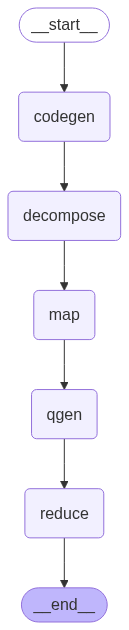

In [12]:
build_assets_app

In [13]:
task = """ 
32. Longest Valid Parentheses
Hard
Topics
premium lock icon
Companies
Given a string containing just the characters '(' and ')', return the length of the longest valid (well-formed) parentheses substring.

 

Example 1:

Input: s = "(()"
Output: 2
Explanation: The longest valid parentheses substring is "()".
Example 2:

Input: s = ")()())"
Output: 4
Explanation: The longest valid parentheses substring is "()()".
Example 3:

Input: s = ""
Output: 0
 

Constraints:

0 <= s.length <= 3 * 104
s[i] is '(', or ')'.
"""

In [14]:
response = build_assets_app.invoke({
  'task_description': task
})

RuntimeError: asyncio.run() cannot be called from a running event loop

In [ ]:
# backend/services/questions.py
import asyncio, uuid
from typing import Dict, Any, List
from backend.workers.question_workers import (
    CognitiveLoad1Worker, CognitiveLoad2Worker, CognitiveLoad3Worker,
    CognitiveLoad4Worker, CognitiveLoad5Worker
)

SEM = asyncio.Semaphore(6)

WORKERS = {
    1: CognitiveLoad1Worker(),
    2: CognitiveLoad2Worker(),
    3: CognitiveLoad3Worker(),
    4: CognitiveLoad4Worker(),
    5: CognitiveLoad5Worker(),
}

def _dedupe(items: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    seen, out = set(), []
    for q in items:
        key = q["question"].strip().lower()
        if key not in seen:
            out.append(q); seen.add(key)
    return out

async def gen_all_levels_for_step(step: Dict[str, Any], code: str,
                                  n_per_level=1, levels=(1,2,3,4,5)) -> Dict[str, Any]:
    async def run(L: int):
        worker = WORKERS[L]
        async with SEM:
            res = await worker.process(
                code=code, step_number=step["step_number"],
                code_snippet=step["code_snippet"], concept=step["concept"],
                explanation=step["explanation"], n=n_per_level, level=L
            )
        if not res.get("success"): return []
        qs = res["questions"]
        for it in qs:
            it["cognitive_load"] = L
            it.setdefault("id", str(uuid.uuid4()))
        return qs

    packs = await asyncio.gather(*[run(L) for L in levels], return_exceptions=True)
    merged: List[Dict[str, Any]] = []
    for p in packs:
        if isinstance(p, list): merged.extend(p)
    merged = _dedupe(merged)
    step = {**step, "questions": step.get("questions", []) + merged}
    return step
